In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix


#Librerias para los modelos
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score


## Para Red Neuronal
from keras.layers import Input, Dense, Embedding, Flatten, Concatenate
from keras.models import Sequential, Model
from keras.optimizers import Adam
import tensorflow as tf

**Preprocesamiento de los Datos**

Buscamos tener numeros en lugar de texto


In [2]:
#predecir los grd mas repetidos (equilibrar los datos)

# Leer los datos
df = pd.read_csv('../data/dataset_elpino.csv', sep = ';')
df_diagnosticos = pd.read_csv('../data/CIE-10.csv', sep = ',')
df_procedimientos = pd.read_excel('../data/CIE-9.xlsx', converters = {'Código': str})
df_grd = pd.read_csv("../data/Tablas maestras bases GRD.csv")

# Haremos un diccionario para (id diagnostico = numero)
contador = 1 
diccionario = {'-': 0}
diccionario_procedimientos = {'-': 0}
diccionario_grd = {'-': 0}


for a in df_diagnosticos['Código']:
    a = a.strip()
    diccionario[a] = contador
    contador  += 1


'''
Asignar numeros a los DIAGNOSTICOS que tenemos en el dataset en funcion de su id 
     En el dataset, hay que separar el nombre del codigo (diagnosticos)
     Para lograrlo en todas las columnas de diagnosticos
        1. recorremos todas las columnas de diagnosticos
        2. recorremos cada fila de esa columna para dejar registrado los numeros que corresponden a cada codigo
        3. agregamos la lista al dataset
        4. eliminamos las columnas que ya no nos sirven
'''
contador = 1
for columns in df.iloc[:, 0:35]:
    lista = []
    indice = df.columns.get_loc(columns)
    for a in df[columns]:
        if a == '-':
            lista.append(diccionario[a])
        #####   PREGUNTAR SI ES NORMAL QUE ESTE CODIGO NO ESTE  #####
        elif a.split('-')[0].strip() not in diccionario:
            #print(a.split('-')[0].strip())
            lista.append(0)
        else:    
            codigo = a.split('-')[0].strip()
            lista.append(diccionario[codigo])

    nombre_columna = f'ID_diagnostico {contador}'
    df.insert(indice, nombre_columna, lista)
    df.drop(columns, axis = 1, inplace=True)
    contador += 1

'''
Asignar numeros a los procedimientos segun su ID
    En el dataset, esta formateado de la siguiente forma (codigo - nombre)
    1. Crear un diccionario de los ids de procedimientos
    2. recorremos las columnas de procedimientos
    3. Agregamos la lista de nuevos ids en el dataset
    4. Eliminamos las columnas que ya no sirven
'''

aux = 1
for codigo in df_procedimientos['Código']:
    codigo = codigo.strip()
    diccionario_procedimientos[codigo] = aux
    aux += 1

contador = 1
for columns in df.iloc[:, 35:65]:
    lista = []
    indice = df.columns.get_loc(columns)
    for a in df[columns]:
        if a == '-':
            lista.append(diccionario_procedimientos[a])
        #####   PREGUNTAR SI ES NORMAL QUE ESTE CODIGO NO ESTE  #####
        elif a.split('-')[0].strip() not in diccionario_procedimientos:
            #print(a.split('-')[0].strip())
            lista.append(0)
        else:
            codigo = a.split('-')[0].strip()
            lista.append(diccionario_procedimientos[codigo])
    #print(lista)
    nombre_columna = f'ID_procedimiento {contador}'
    df.insert(indice, nombre_columna, lista)
    df.drop(columns, axis = 1, inplace=True)
    contador += 1

'''
Mantener los IDs de los GRDs como los numeros para identificarlos 
1. Meterse a cada fila
2. Separar el texto y mantener los IDs
'''

contador = 1

df_grd.head()
for a in df_grd["IR- GRD"]:
    diccionario_grd[a] = contador
    contador += 1

lista = []
for a in df['GRD']:
    id = int(a.split('-')[0].strip())
    lista.append(diccionario_grd[id])

nombre_columna = 'ID_GRD'
df.insert(68, nombre_columna, lista)
df.drop("GRD", axis = 1, inplace=True)

sexo = {'Hombre': 1, 'Mujer': 0}
df['Sexo (Desc)'] = df['Sexo (Desc)'].map(sexo)

display(df)



,ID_diagnostico 1,ID_diagnostico 2,ID_diagnostico 3,ID_diagnostico 4,ID_diagnostico 5,ID_diagnostico 6,ID_diagnostico 7,ID_diagnostico 8,ID_diagnostico 9,ID_diagnostico 10,...,ID_procedimiento 24,ID_procedimiento 25,ID_procedimiento 26,ID_procedimiento 27,ID_procedimiento 28,ID_procedimiento 29,ID_procedimiento 30,Edad en años,Sexo (Desc),ID_GRD
0,227,627,3857,10582,895,5295,4984,896,226,4395,...,4633,3895,4030,4038,4108,4104,3751,40,1,913
1,14738,4202,12605,12603,12771,39329,39179,4423,4409,4400,...,4127,4031,4108,4038,4103,4441,4075,53,1,178
2,4739,12787,12786,4380,39158,4207,14749,890,902,622,...,4633,4136,4039,4579,3960,3989,3988,65,1,178
3,4872,4810,10630,1874,2373,2370,4381,10623,4321,12717,...,2334,11,15,4555,4570,4574,4576,61,1,181
4,14587,39106,13299,13385,23644,4425,4207,14749,14738,10712,...,4038,4108,4103,4277,4567,4441,1756,30,1,181
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14556,2033,4326,2442,2519,39795,0,0,0,0,0,...,0,0,0,0,0,0,0,26,0,627
14557,13109,22561,12780,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,10,1,77
14558,4943,3734,2052,3931,4600,6210,3037,39872,0,0,...,0,0,0,0,0,0,0,58,1,427
14559,2322,3734,39805,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,47,1,633


**Analisis Exploratorio de los Datos**

Tomar los GRD's mas repetidos en el dataset y hacer un nuevo dataset mas equilibrado


33


<Axes: xlabel='ID_GRD', ylabel='Count'>

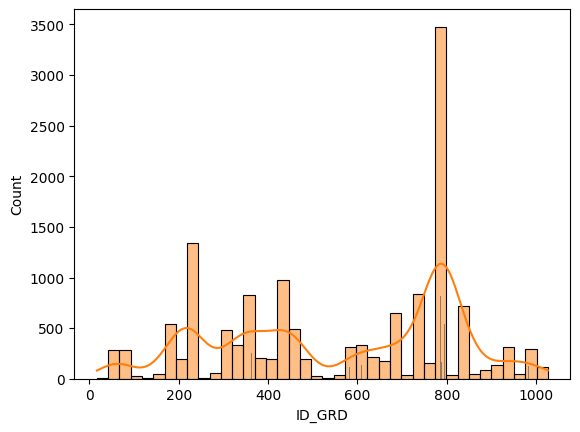

In [75]:
frecuencia = {}
for id in df['ID_GRD']:
    if id not in frecuencia:
        frecuencia[id] = 1
    else:
        frecuencia[id] += 1

moda = {}
for i in frecuencia:
    if frecuencia[i] >= 100:
        moda[i] = frecuencia[i]

ejex = list(moda.keys())
ejey = list(moda.values())    

nuevos_ids = {}
id = 0
for a in ejex:
    nuevos_ids[a] = id
    id += 1

print(len(moda))
plt.bar(ejex, ejey)
sns.histplot(df['ID_GRD'], bins=40, kde=True)

In [76]:
nuevo_dataset = pd.DataFrame()

fila = 0 
for a in df['ID_GRD']:
    if a not in ejex:
        pass
    else:
        fila_copia = df.iloc[fila]
        nuevo_dataset = pd.concat([nuevo_dataset, pd.DataFrame([fila_copia])], ignore_index=True)
    fila += 1

nuevo_dataset['ID_GRD'] = nuevo_dataset['ID_GRD'].replace(nuevos_ids)
nuevo_dataset.head()

,ID_diagnostico 1,ID_diagnostico 2,ID_diagnostico 3,ID_diagnostico 4,ID_diagnostico 5,ID_diagnostico 6,ID_diagnostico 7,ID_diagnostico 8,ID_diagnostico 9,ID_diagnostico 10,...,ID_procedimiento 24,ID_procedimiento 25,ID_procedimiento 26,ID_procedimiento 27,ID_procedimiento 28,ID_procedimiento 29,ID_procedimiento 30,Edad en años,Sexo (Desc),ID_GRD
0,4872,4810,10630,1874,2373,2370,4381,10623,4321,12717,...,2334,11,15,4555,4570,4574,4576,61,1,0
1,14587,39106,13299,13385,23644,4425,4207,14749,14738,10712,...,4038,4108,4103,4277,4567,4441,1756,30,1,0
2,14738,4202,4380,39275,39329,39179,14591,39110,4913,4805,...,4555,4570,4571,4574,4579,4582,4196,37,0,0
3,14738,4202,4423,12771,12632,12603,8186,12615,70,39329,...,4579,4582,4196,4204,4206,4207,4208,59,1,0
4,10620,4881,14738,4425,3913,12785,227,895,39158,14749,...,3828,3865,3751,3859,3786,1756,1764,77,0,0


Text(0, 0.5, 'Cantidad de datos')

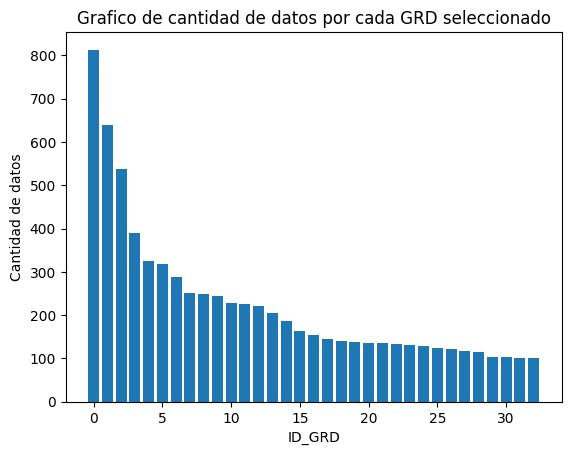

In [77]:
ejey = nuevo_dataset['ID_GRD'].value_counts()
ejex = list(nuevos_ids.values())

plt.bar(ejex, ejey)
plt.title('Grafico de cantidad de datos por cada GRD seleccionado')
plt.xlabel('ID_GRD')
plt.ylabel('Cantidad de datos')

**MODELOS Y ENTRENAMIENTOS**
- Los datos de diagnosticos y procedimientos no representan cantidades ni magnitudes, por lo tanto, debemos ocupar un modelo que ocupe variables categoricas

- Modelos que podemos utilizar 
    - **Decision Tree**
    - **Random Forest**
    - **KNN**

In [78]:
# Separamos los datos en dos: datos de entrenamiento y datos de prueba
lista = []
for a in nuevo_dataset:
    if a != 'ID_GRD':
        lista.append(a)

x = nuevo_dataset[lista]
y = nuevo_dataset['ID_GRD']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, stratify = y, random_state = 42)

######### Random Forest #########
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

predicciones_random_forest = random_forest_model.predict(X_test)
print('Accuracy Random Forest: ', round(np.mean(predicciones_random_forest == y_test), 2))

######### Decision Tree #########
decision_tree_model = DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=42)
decision_tree_model.fit(X_train, y_train)

predicciones_decision_tree = decision_tree_model.predict(X_test)
print('Accuracy Decision Tree: ', round(np.mean(predicciones_decision_tree == y_test), 2))

Accuracy Random Forest:  0.82
Accuracy Decision Tree:  0.81


In [85]:
predicciones_decision_tree

array([27, 10,  9, ..., 12,  9,  9])

**Matrices de Confusión**
- Teniendo en cuenta que nuestros datos estan desbalanceados los accuracy pueden no ser del todo representativos, por este motivo graficaremos las matrices de confusion de los dos modelos

In [91]:
# Ploteamos matrices de confusion para los dos modelos

'''
A cada matriz de confusion tenemos que agregar la matriz de confusion normalizada, ya que, 
los datos que tenemos en cada clase estan desbalanceados 
'''

def matrices_confusion(reales, predicciones, title):
    matriz = confusion_matrix(reales, predicciones)
    matriz_normalizada = matriz.astype('float') / matriz.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(5, 5))
    plt.imshow(matriz_normalizada, cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicciones')
    plt.ylabel('Real')
    plt.colorbar()
    plt.show()


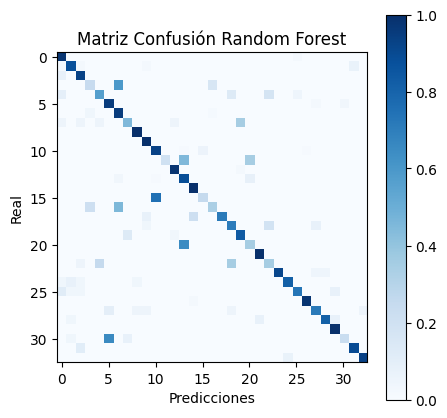

In [92]:
matrices_confusion(y_test, predicciones_random_forest, 'Matriz Confusión Random Forest')

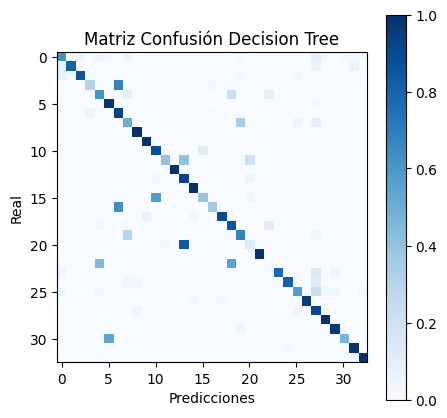

In [93]:
matrices_confusion(y_test, predicciones_decision_tree, 'Matriz Confusión Decision Tree')

**Red Neuronal**
- A partir de los resultados anteriores, intentaremos mejorar el accuracy ocupando **Redes Neuronales**

In [82]:
red_neuronal = Sequential()
red_neuronal.add(Input(shape=(x.shape[1],)))
red_neuronal.add(Dense(128, activation='relu'))
red_neuronal.add(Dense(33, activation='softmax'))
red_neuronal.summary()
optimizer = Adam(learning_rate=1e-3)
red_neuronal.compile(optimizer = optimizer, loss='sparse_categorical_crossentropy', metrics = ['accuracy'])


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 128)            │         8,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 33)             │         4,257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,961 (50.63 KB)

 Trainable params: 12,961 (50.63 KB)

 Non-trainable params: 0 (0.00 B)

In [83]:
red_neuronal.fit(X_train, y_train, validation_data=(X_test, y_test), batch_size=64, epochs=32,verbose=1)
predicciones = red_neuronal.predict(X_test)

Epoch 1/32
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1289 - loss: 4471.8281 - val_accuracy: 0.2422 - val_loss: 1272.7340
Epoch 2/32
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2389 - loss: 1102.5576 - val_accuracy: 0.2773 - val_loss: 847.1994
Epoch 3/32
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2999 - loss: 651.7538 - val_accuracy: 0.2713 - val_loss: 686.9260
Epoch 4/32
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3285 - loss: 501.7451 - val_accuracy: 0.2962 - val_loss: 588.5152
Epoch 5/32
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3467 - loss: 416.5914 - val_accuracy: 0.3374 - val_loss: 513.5786
Epoch 6/32
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3517 - loss: 375.0869 - val_accuracy: 0.3367 - val_loss: 505.5034
Epoch 7/32
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3695 - loss: 323.7991 - val_accuracy: 0.3239 - val_loss: 456.3460
Epoch 8/32
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4038 - loss: 286.8444 -

In [84]:
predicciones_red_neuronal = []
for i in range(len(predicciones)):
    index = 0
    for j in predicciones[i]:
        if max(predicciones[i]) == j:
            predicciones_red_neuronal.append(index)
            break
        index += 1

print('Accuracy Red Neuronal: ', round(np.mean(predicciones_red_neuronal == y_test), 2))

Accuracy Red Neuronal:  0.38


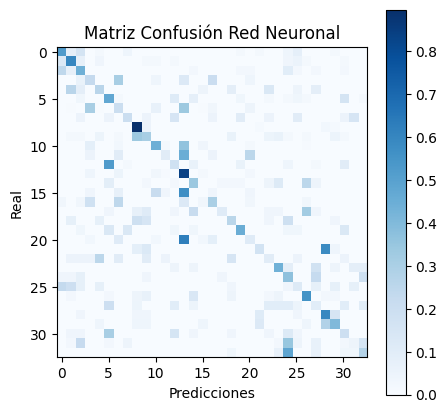

In [94]:
matrices_confusion(y_test, predicciones_red_neuronal, 'Matriz Confusión Red Neuronal')

**NOTA**
- Probablemente la explicacion de que el accuracy de la Red Neuronal sea tan bajo y las predicciones dejen tanto que desear, sea debido a que, este modelo esta intentando encontrar relaciones entre los numeros de los IDs y en nuestro caso esas relaciones no existe, por lo que, ocuparemos embeddings para mejorar el desempeño de nuestra Red Neuronal

In [106]:
n_diagnosticos = len(diccionario)
n_procedimientos = len(diccionario_procedimientos)

inputs_diag = [Input(shape=(1,), name=f'diag_{i}') for i in range(35)]
inputs_proc = [Input(shape=(1,), name=f'proc_{i}') for i in range(30)]

input_edad = Input(shape=(1,), name='edad')
input_sexo = Input(shape=(1,), name='sexo')

embedding_diagnosticos = Embedding(input_dim=n_diagnosticos, output_dim=128)
embedding_procedimientos = Embedding(input_dim=n_procedimientos, output_dim=64)

embedded_diags = [Flatten()(embedding_diagnosticos(inp)) for inp in inputs_diag]
embedded_procs = [Flatten()(embedding_procedimientos(inp)) for inp in inputs_proc]

all_embeddings = Concatenate()(embedded_diags + embedded_procs)
full_input = Concatenate()([all_embeddings, input_edad, input_sexo])

x = Dense(256, activation='relu')(full_input)
x = Dense(128, activation='relu')(x)
output = Dense(33, activation='softmax')(x)

modelo = Model(inputs=inputs_diag + inputs_proc + [input_edad, input_sexo], outputs=output)
modelo.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

modelo.summary()




Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ diag_0 (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_1 (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_2 (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_3 (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_4 (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_5 (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_6 (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_7 (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_8 (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_9 (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_10             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_11             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_12             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_13             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_14             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_15             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_16             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_17             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_18             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_19             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                 

 Total params: 7,077,601 (27.00 MB)

 Trainable params: 7,077,601 (27.00 MB)

 Non-trainable params: 0 (0.00 B)

In [120]:
columnas_diagnosticos = nuevo_dataset.columns[0:35]

X_train_inputs = [X_train[col_name].values for col_name in columnas_diagnosticos]
X_test_inputs = [X_test[col_name].values for col_name in columnas_diagnosticos]


In [ ]:
red_neuronal.compile(optimizer=Adam(learning_rate=1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
red_neuronal.fit(X_train_inputs, y_train, validation_data=(X_test_inputs, y_test), batch_size=64, epochs=32, verbose=1)